# 1.11 AR(1) 随机过程与均值回归


> **这一节讲什么？**
> 
> AR(1) 是最简单也最重要的时间序列模型：今天的值等于昨天的值乘以一个系数加随机扰动。它是理解均值回归策略、利率模型（OU过程）和卡尔曼滤波的基础。

## 学习目标
- 理解 AR(1) 过程的平稳性条件和参数估计
- 计算均值回归速度（半衰期）
- 在配对交易中应用 AR(1) 建模价差
- 了解连续时间的 Ornstein-Uhlenbeck（OU）过程


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Libraries loaded')


Libraries loaded


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. AR(1) 过程定义

$$X_t = \mu + \phi (X_{t-1} - \mu) + \epsilon_t, \quad \epsilon_t \sim N(0, \sigma^2)$$

- $\mu$：长期均值（均值回归的「引力中心」）
- $\phi$：自回归系数（$|\phi| < 1$ 时过程平稳）
- 平稳条件：$|\phi| < 1$

**量化金融意义**：
- $\phi$ 接近 1 → 接近随机游走（趋势跟踪）
- $\phi$ 接近 0 → 快速回归均值（均值回归策略）
- $\phi < 0$ → 过度震荡（每期都过度修正）


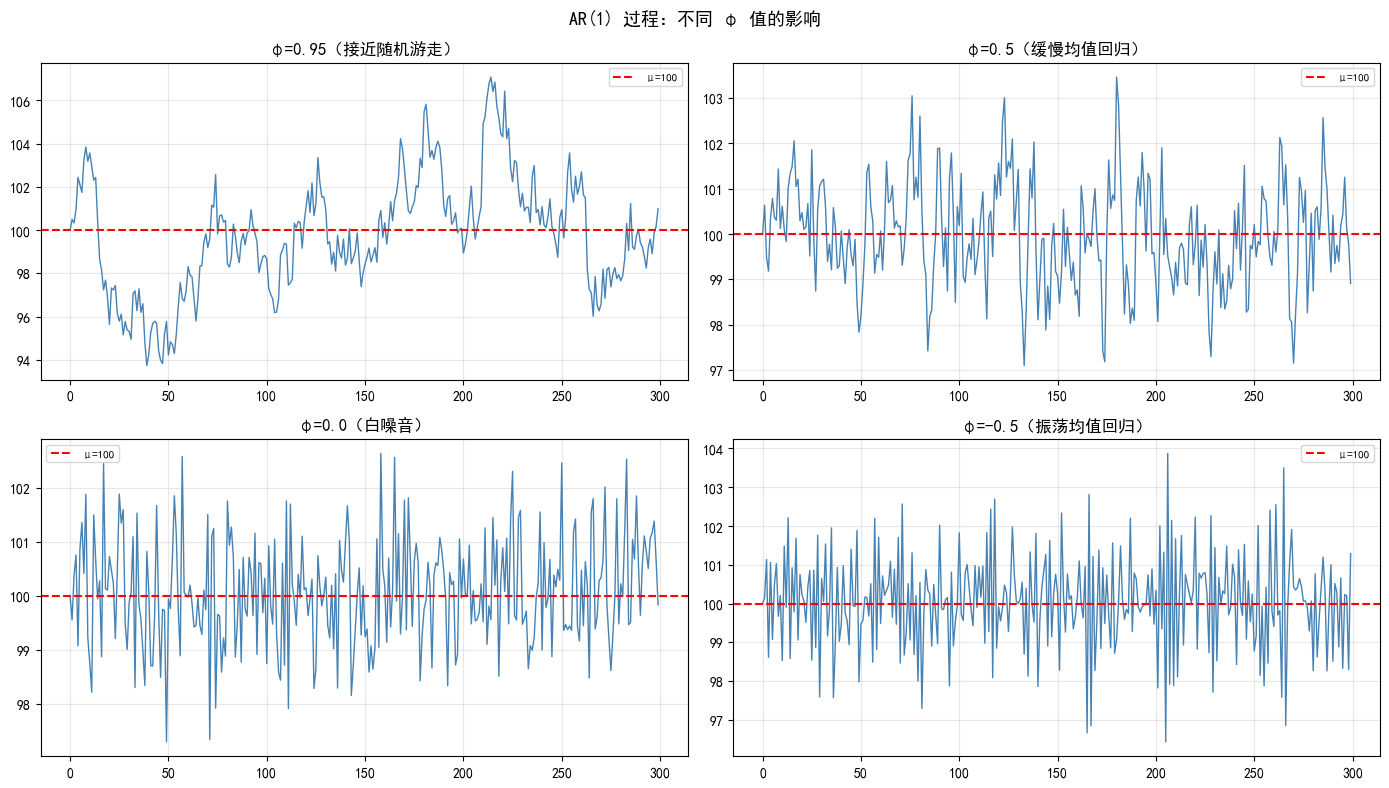

In [3]:
# 演示不同 phi 值的 AR(1) 轨迹
np.random.seed(42)
n = 300
mu = 100
sigma = 1

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
phi_values = [0.95, 0.5, 0.0, -0.5]
titles = ['φ=0.95（接近随机游走）', 'φ=0.5（缓慢均值回归）',
          'φ=0.0（白噪音）', 'φ=-0.5（振荡均值回归）']

for ax, phi, title in zip(axes.flat, phi_values, titles):
    X = np.zeros(n)
    X[0] = mu
    for t in range(1, n):
        X[t] = mu + phi * (X[t-1] - mu) + np.random.normal(0, sigma)
    ax.plot(X, color='steelblue', lw=1)
    ax.axhline(mu, color='red', linestyle='--', lw=1.5, label=f'μ={mu}')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('AR(1) 过程：不同 φ 值的影响', fontsize=13)
plt.tight_layout(); plt.show()


## 2. 均值回归半衰期

AR(1) 过程的「均值回归半衰期」：偏离均值的一半距离期望需要多少时间回归。

$$\text{Half-Life} = \frac{-\ln(2)}{\ln(\phi)}$$


In [4]:
print('AR(1) 均值回归半衰期:')
print(f'{'φ':>8s} {'半衰期（天）':>15s} {'适合策略':>20s}')
print('-' * 50)
for phi in [0.99, 0.95, 0.90, 0.80, 0.60, 0.20]:
    hl = -np.log(2) / np.log(abs(phi))
    strategy = '趋势跟踪' if phi > 0.9 else ('缓慢均回' if phi > 0.6 else '快速均回')
    print(f'{phi:>8.2f} {hl:>15.1f} {strategy:>20s}')


AR(1) 均值回归半衰期:
       φ          半衰期（天）                 适合策略
--------------------------------------------------
    0.99            69.0                 趋势跟踪
    0.95            13.5                 趋势跟踪
    0.90             6.6                 缓慢均回
    0.80             3.1                 缓慢均回
    0.60             1.4                 快速均回
    0.20             0.4                 快速均回


## 3. 实际应用：估计配对交易价差的 AR(1) 参数


真实 φ: 0.850   估计 φ: 0.8264
真实 μ: 0.000   估计 μ: -0.0236
估计均值回归半衰期: 3.6 天


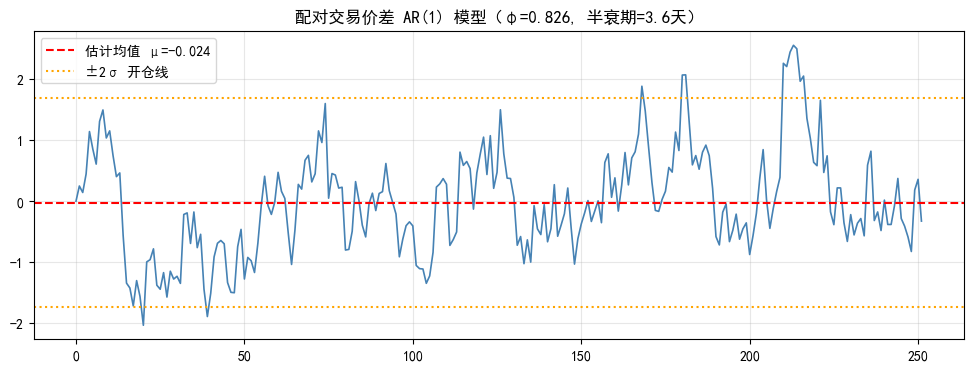

In [5]:
# 模拟一对协整股票的价差（AR(1) 均值回归过程）
np.random.seed(42)
phi_true = 0.85
mu_true = 0
sigma_true = 0.5
n = 252

spread = np.zeros(n)
for t in range(1, n):
    spread[t] = mu_true + phi_true*(spread[t-1]-mu_true) + np.random.normal(0, sigma_true)

# OLS 估计 AR(1) 参数
df = pd.DataFrame({'y': spread[1:], 'x': spread[:-1]})
result = sm.OLS(df['y'], sm.add_constant(df['x'])).fit()
phi_hat = result.params['x']
mu_hat = result.params['const'] / (1 - phi_hat)
half_life = -np.log(2) / np.log(abs(phi_hat))

print(f'真实 φ: {phi_true:.3f}   估计 φ: {phi_hat:.4f}')
print(f'真实 μ: {mu_true:.3f}   估计 μ: {mu_hat:.4f}')
print(f'估计均值回归半衰期: {half_life:.1f} 天')

plt.figure(figsize=(12, 4))
plt.plot(spread, color='steelblue', lw=1.2)
plt.axhline(mu_hat, color='red', linestyle='--', lw=1.5, label=f'估计均值 μ={mu_hat:.3f}')
plt.axhline(mu_hat + 2*spread.std(), color='orange', linestyle=':', label='±2σ 开仓线')
plt.axhline(mu_hat - 2*spread.std(), color='orange', linestyle=':')
plt.title(f'配对交易价差 AR(1) 模型（φ={phi_hat:.3f}, 半衰期={half_life:.1f}天）')
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 4. Ornstein-Uhlenbeck 过程（连续时间 AR(1)）

AR(1) 的连续时间版本是 **Ornstein-Uhlenbeck（OU）过程**：

$$dX_t = \kappa(\theta - X_t)dt + \sigma dW_t$$

- $\kappa$：均值回归速度（越大越快）
- $\theta$：长期均值
- $\sigma$：波动率

对应 AR(1) 中：$\phi \approx e^{-\kappa \Delta t}$，从而 $\kappa = -\ln(\phi)/\Delta t$


In [6]:
# OU 过程参数与 AR(1) 的对应
phi = 0.85
dt = 1/252  # 日频
kappa = -np.log(phi) / dt
print(f'AR(1) φ={phi} 对应 OU 过程 κ={kappa:.2f} (年化均值回归速度)')
print(f'半衰期: {np.log(2)/kappa*252:.1f} 天 = {np.log(2)/kappa:.2f} 年')

# 模拟 OU 过程
np.random.seed(42)
T_years = 2
np.random_steps = int(T_years * 252)
kappa_sim = 3.0  # 年化均值回归速度
theta = 0.0
sigma_ou = 0.5
X = np.zeros(252)
for t in range(1, 252):
    dX = kappa_sim * (theta - X[t-1]) * dt + sigma_ou * np.sqrt(dt) * np.random.randn()
    X[t] = X[t-1] + dX

print(f'OU 模拟: kappa={kappa_sim}, 半衰期={(np.log(2)/kappa_sim*252):.0f}天')


AR(1) φ=0.85 对应 OU 过程 κ=40.95 (年化均值回归速度)
半衰期: 4.3 天 = 0.02 年
OU 模拟: kappa=3.0, 半衰期=58天


## 🎯 练习

1. 对 A/H 股溢价率序列（同一家公司的 A 股 vs 港股）进行 AR(1) 拟合，估计其均值回归半衰期。
2. 对比 DF 检验（Dickey-Fuller）的统计量与 AR(1) 中 φ=1 的原假设，理解二者的关系。
3. 实现一个实时更新的 AR(1) 配对交易策略：当 |spread - μ| > 2σ 时开仓，回到 |spread - μ| < 0.5σ 时平仓。

---
**下一节** → `../10_math_methods/01_monte_carlo.ipynb`